Agglomerative Hierarchical Clustering ek unsupervised machine learning algorithm hai jo similar data points ko gradually clusters/groups mein combine karta hai.

**“Har point se start karo → closest groups ko baar-baar merge karo → end mein ek bada cluster/tree ban jaata hai.”**

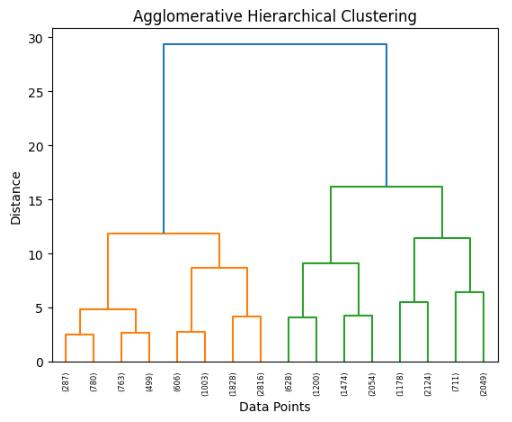

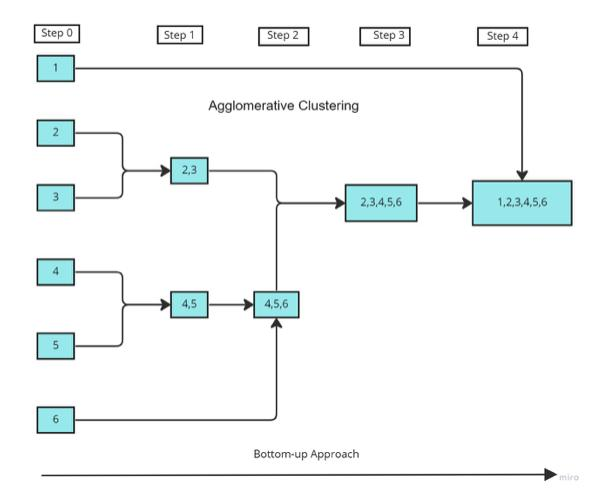

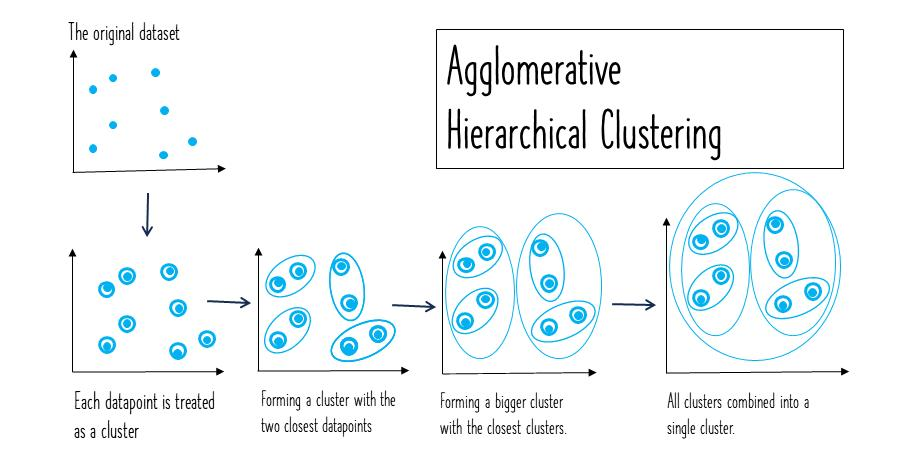

# 1. Agglomerative ka meaning

Agglomerative = Merge karna

Imagine 5 students hain:

A   B   C   D   E

Initially:

[A] [B] [C] [D] [E]

Har student apna separate cluster hai.

Phir algorithm closest students ko merge karega:

[AB] [C] [D] [E]

Phir:

[AB] [CD] [E]

Phir:

[ABCD] [E]

Finally:

[ABCDE]

That's why it's called bottom-up clustering

# 2. Main Idea

Agglomerative clustering ka process:

Step 1 → Har data point = separate cluster

Step 2 → Closest 2 clusters find karo

Step 3 → Unko merge karo

Step 4 → Again closest 2 clusters find karo

Step 5 → Merge

Step 6 → Repeat

Until:

All points → One big cluster

# 3. Simple Example

Suppose students ke marks hain:

A = 90

B = 92

C = 50

D = 52

E = 20

Initially:

[A] [B] [C] [D] [E]

Distances:

A-B = 2

C-D = 2

So closest:

[A B]

[C D]

[E]

Now:

[AB] [CD] [E]

Suppose [CD] and [E] are closest next:

[AB] [CDE]

Finally:

[ABCDE]

# 4. But algorithm ko "closest" kaise pata?

Yahan linkage important hai.

Two clusters ke beech distance calculate karne ke different methods hain.

* Single Linkage

Do clusters ke closest points ka distance.

Cluster A        Cluster B

●                  ●

       ●         ●


Minimum distance choose hota hai.

* Complete Linkage

Do clusters ke farthest points ka distance.

Maximum distance

* Average Linkage

Clusters ke all pair distances ka average.

* Ward Linkage ⭐

Clusters merge karta hai in a way that within-cluster variance minimum increase ho.

Practical ML mein ward commonly useful hota hai.




# 5. Dendrogram

Agglomerative clustering ka sabse important visual concept:

Dendrogram

Example:

             ┌───────────────┐
             │               │
          ┌──┴──┐          ┌─┴─┐
          │     │          │   │
        ┌─┴─┐   C          D   E
        A   B


Ye tree batata hai ki kaunse clusters kis stage par merge hue.

Height kya batati hai?

Height = distance/dissimilarity at which clusters merge.

Low height:

Very similar

High height:

Very different

# 6. Number of clusters kaise choose kare?

Dendrogram mein horizontal line imagine karo:

             ┌─────────────┐
             │             │
       ┌─────┴─────┐       │
       │           │       │
    ┌──┴──┐      ┌─┴─┐     │
    A    B       C   D     E


Agar hum yahan cut karein:

--------------------------

to jitni branches cut hongi, utne clusters.

For example:

Cluster 1 → A B

Cluster 2 → C D

Cluster 3 → E

So:

n_clusters = 3

# K-Means vs Agglomerative

| K-Means                                  | Agglomerative                              |
| ---------------------------------------- | ------------------------------------------ |
| Centroid based                           | Hierarchy/tree based                       |
| K pehle specify karna padta hai          | Dendrogram se decide kar sakte ho          |
| Iteratively centroids update karta hai   | Clusters merge karta hai                   |
| Usually faster                           | Usually more computationally expensive     |
| Mostly spherical clusters ke liye useful | Different structures capture kar sakta hai |


Easy memory:

K-Means = Centre find karo

Agglomerative = Closest groups merge karo

In [ ]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels = model.fit_predict(X)

print(labels)


Suppose output:

[0, 0, 1, 1, 2, 2]

Means:

Cluster 0 → points 1,2

Cluster 1 → points 3,4

Cluster 2 → points 5,6

# Agglomerative Hierarchical Clustering is an unsupervised clustering technique that starts with each data point as an individual cluster and repeatedly merges the most similar/closest clusters to form a hierarchy.

# Types of Hierarchical Clustering

1. Agglomerative Hierarchical Clustering

Bottom-Up approach.

Har data point initially alag cluster hota hai:

[A] [B] [C] [D] [E]

Phir similar/closest clusters ko merge karte hain:

[AB] [C] [DE]

Then:

[ABC] [DE]

Finally:

[ABCDE]

👉 Agglomerative = Merge

Yaad rakho:

A → Agglomerative → Add/Merge

# 2. Divisive Hierarchical Clustering

Top-Down approach.

Starting mein sabhi points ek hi cluster mein hote hain:

[ABCDE]

Phir cluster ko divide/split karte hain:

[ABC] [DE]

Then:

[AB] [C] [D] [E]

Finally individual clusters:

[A] [B] [C] [D] [E]

👉 Divisive = Split

Yaad rakho:

D → Divisive → Divide

# One-line trick

Agglomerative = Join 🤝

Divisive = Break ✂️

# How to find the ideal number of clusters“Kitne clusters banane chahiye?”

Ideal Number of Clusters
        │
        ├── 1. Elbow Method
        ├── 2. Silhouette Score
        └── 3. Dendrogram

1. Elbow Method — K-Means ⭐

K-Means mein different K values try karte hain:

K = 1
K = 2
K = 3
K = 4
K = 5
...

Har K ke liye WCSS / Inertia calculate karte hain.

Graph:

WCSS
 │
 │\
 │ \
 │  \
 │   \__
 │      \__
 │         \____
 └──────────────── K
       ↑
     Elbow


Jahan graph ki speed se decrease hona suddenly slow ho jaata hai, us point ko Elbow Point kehte hain.

👉 Elbow Point ≈ ideal K

Memory:

Elbow Method → Elbow dekho → K choose karo




2. Silhouette Score ⭐

Silhouette Score check karta hai:

“Kya points apne cluster ke andar close hain aur doosre clusters se far hain?”

Score range:

-1 -------- 0 -------- +1
Bad       Random       Good

Generally:


Close to +1 → clusters well separated

Around 0 → clusters overlap

Negative → wrong clustering possible

Different K values ke scores calculate karo:

K = 2 → 0.51
K = 3 → 0.67  ← Best
K = 4 → 0.59
K = 5 → 0.52

So:

Ideal K = 3

👉 Highest Silhouette Score = generally better clustering

3. Dendrogram 🌳 — Hierarchical Clustering

Hierarchical clustering mein dendrogram use karte hain.

Example:

Distance
   |
10 |          ┌───────────┐
   |          │           │
 7 |     ┌────┘           │
   |     │                │
 4 |  ┌──┴──┐          ┌──┴──┐
   |  A     B          C     D
   |
   └──────────────────────────

Ek horizontal cut imagine/draw karo.

-------------------  ← Cut

Jitni branches cut hoti hain, utne clusters milte hain.

So:

Dendrogram → Cut the tree → Count branches → Number of clusters

 # Benefits and Limitations of Agglomerative Hierarchical Clustering

 ✅ Benefits

1. No need to choose K initially

Unlike K-Means, you can create a dendrogram first and decide the number of clusters later.

2. Easy to visualize 🌳

Dendrogram clearly shows how clusters are merged.

3. Works with different cluster shapes

It can identify structures that may not work well with simple centroid-based methods.
4. No need for initial centroids

Unlike K-Means, there is no need to randomly initialize cluster centres.

5. Hierarchy of clusters
It gives information at multiple levels:

Small clusters → Bigger clusters → One big cluster

Useful for small/medium datasets

It is particularly useful when understanding the relationships between data points is important.

# ❌ Limitations
1. Computationally expensive

It can become slow when the dataset is very large.

2. Memory intensive

Distance calculations between many points can require significant memory.

3. Sensitive to noise and outliers

An outlier can affect the merging process.
4. Merging cannot be undone

Once two clusters are merged, the algorithm generally cannot separate them later.

5. Linkage choice matters

Results can change depending on:

Single Linkage

Complete Linkage

Average Linkage

Ward Linkage

6. Sensitive to scaling

If features have very different ranges, distance calculations can become misleading. Feature scaling is often needed.